# Домашнее задание 2. Классификация изображений.

В этом задании потребуется обучить классификатор изображений. Будем работать с датасетом, название которого раскрывать не будем. Можете посмотреть самостоятельно на картинки, которые в есть датасете. В нём 200 классов и около 5 тысяч картинок на каждый класс. Классы пронумерованы, как нетрудно догадаться, от 0 до 199. Скачать датасет можно вот [тут](https://yadi.sk/d/BNR41Vu3y0c7qA).

Структура датасета простая -- есть директории train/ и val/, в которых лежат обучающие и валидационные данные. В train/ и val/ лежат директориии, соответствующие классам изображений, в которых лежат, собственно, сами изображения.

__Задание__. Необходимо выполнить два задания

1) Добейтесь accuracy **на валидации не менее 0.44**. В этом задании **запрещено** пользоваться предобученными моделями и ресайзом картинок. 5 баллов

2) Добейтесь accuracy **на валидации не менее 0.84**. В этом задании делать ресайз и использовать претрейн можно. 5 баллов

Напишите краткий отчёт о проделанных экспериментах. Что сработало и что не сработало? Почему вы решили, сделать так, а не иначе? Обязательно указывайте ссылки на чужой код, если вы его используете. Обязательно ссылайтесь на статьи / блогпосты / вопросы на stackoverflow / видосы от ютуберов-машинлернеров / курсы / подсказки от Дяди Васи и прочие дополнительные материалы, если вы их используете.

Ваш код обязательно должен проходить все `assert`'ы ниже.

__Использовать внешние данные для обучения строго запрещено в обоих заданиях. Также запрещено обучаться на валидационной выборке__.


__Критерии оценки__: Оценка вычисляется по простой формуле: `min(10, 10 * Ваша accuracy / 0.44)` для первого задания и `min(10, 10 * (Ваша accuracy - 0.5) / 0.34)` для второго. Оценка округляется до десятых по арифметическим правилам.


__Советы и указания__:
 - Наверняка вам потребуется много гуглить о классификации и о том, как заставить её работать. Это нормально, все гуглят. Но не забывайте, что нужно быть готовым за скатанный код отвечать :)
 - Используйте аугментации. Для этого пользуйтесь модулем `torchvision.transforms` или библиотекой [albumentations](https://github.com/albumentations-team/albumentations)
 - Можно обучать с нуля или файнтюнить (в зависимости от задания) модели из `torchvision`.
 - Рекомендуем написать вам сначала класс-датасет (или воспользоваться классом `ImageFolder`), который возвращает картинки и соответствующие им классы, а затем функции для трейна по шаблонам ниже. Однако делать это мы не заставляем. Если вам так неудобно, то можете писать код в удобном стиле. Однако учтите, что чрезмерное изменение нижеперечисленных шаблонов увеличит количество вопросов к вашему коду и повысит вероятность вызова на защиту :)
 - Валидируйте. Трекайте ошибки как можно раньше, чтобы не тратить время впустую.
 - Чтобы быстро отладить код, пробуйте обучаться на маленькой части датасета (скажем, 5-10 картинок просто чтобы убедиться что код запускается). Когда вы поняли, что смогли всё отдебажить, переходите обучению по всему датасету
 - На каждый запуск делайте ровно одно изменение в модели/аугментации/оптимайзере, чтобы понять, что и как влияет на результат.
 - Фиксируйте random seed.
 - Начинайте с простых моделей и постепенно переходите к сложным. Обучение лёгких моделей экономит много времени.
 - Ставьте расписание на learning rate. Уменьшайте его, когда лосс на валидации перестаёт убывать.
 - Советуем использовать GPU. Если у вас его нет, используйте google colab. Если вам неудобно его использовать на постоянной основе, напишите и отладьте весь код локально на CPU, а затем запустите уже написанный ноутбук в колабе. Авторское решение задания достигает требуемой точности в колабе за 15 минут обучения.

Good luck & have fun! :)

In [ ]:
# !pip install wandb
#!pip3 install pytorch_lightning torchmetrics

In [2]:
import math
import os
import random
import sys

import matplotlib.pyplot as plt
import numpy as np
import pytorch_lightning as pl
import torch
import torchvision
import torchvision.transforms as transforms
from PIL import Image
from pytorch_lightning.loggers import WandbLogger
from torch import nn
from torch.nn import functional as F
from torch.utils.data import DataLoader
from torchmetrics.functional import accuracy
from torchvision.datasets import ImageFolder
from tqdm import tqdm
from torchvision.transforms import Compose, Normalize, Resize, ToTensor
from torchvision.transforms import RandomHorizontalFlip, RandomRotation, RandomAffine
from torchvision.transforms import ColorJitter, RandomResizedCrop, GaussianBlur
from torchvision.datasets import ImageFolder
from pytorch_lightning.tuner import Tuner
from torchvision import models
import torchmetrics
import pytorch_lightning as pl

# You may add any imports you need

In [3]:
torch.set_float32_matmul_precision('high')

In [4]:
def seed_everything(seed):
    # Фискирует максимум сидов.
    # Это понадобится, чтобы сравнение оптимизаторов было корректным
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True


seed_everything(123456)

In [ ]:
#!wget https://www.dropbox.com/s/33l8lp62rmvtx40/dataset.zip?dl=1 -O dataset.zip && unzip -q dataset.zip

## Задание 0

### Что поможет сделать на 10 из 10 (одно задание - 5 баллов)

1. Использовать все возможные методы оптимизации и эксперемнтировать с ними.
2. Подбор learning rate. Пример из прошлого семинара как это делать: [Как найти lr](https://pytorch-lightning.readthedocs.io/en/1.4.5/advanced/lr_finder.html)

```
  trainer = pl.Trainer(accelerator="gpu", max_epochs=2, auto_lr_find=True)

  trainer.tune(module, train_dataloader, eval_dataloader)

  trainer.fit(module, train_dataloader, eval_dataloader))
```



3. Аугментация данных. [Документация (полезная)](https://pytorch.org/vision/main/transforms.html), а также [библиотека albumentation](https://towardsdatascience.com/getting-started-with-albumentation-winning-deep-learning-image-augmentation-technique-in-pytorch-47aaba0ee3f8)
4. Подбор архитектуры модели.
5. Можно написать модель руками свою в YourNet, а можно импортировать не предобученную сетку известной архитектуры из модуля torchvision.models. Один из способов как можно сделать:

  * `torchvision.models.resnet18(pretrained=False, num_classes=200).to(device)`
  * Документация по возможным моделям и как их можно брать: [Документация (полезная)](https://pytorch.org/vision/stable/models.html)
6. Правильно нормализовывать данные при создании, пример [тык, но тут и в целом гайд от и до](https://www.pluralsight.com/guides/image-classification-with-pytorch)
7. Model Checkpointing. Сохраняйте свой прогресс (модели), чтобы когда что-то пойдет не так вы сможете начать с этого места или просто воспроизвести свои результаты модели, которые обучали.
 * Пример как можно с wandb тут: [Сохраняем лучшие модели в wandb](https://docs.wandb.ai/guides/integrations/lightning)
 * По простому можно так: [Сохраняем модели в pytorch дока](https://pytorch.org/tutorials/beginner/saving_loading_models.html)

### Подготовка данных

In [30]:
def matplotlib_imshow(img, one_channel=False):
    if one_channel:
        img = img.mean(dim=0)
    img = img / 2 + 0.5
    npimg = img.numpy()
    if one_channel:
        plt.imshow(npimg, cmap="Greys")
    else:
        plt.imshow(np.transpose(npimg, (1, 2, 0)))

In [31]:
def compute_mean_std(dataset):
    dataloader = DataLoader(dataset, batch_size=64, num_workers=4)
    mean = torch.zeros(3)
    std = torch.zeros(3)
    total_samples = 0

    for images, _ in dataloader:
        batch_samples = images.size(0)
        images = images.view(batch_samples, 3, -1)
        mean += images.mean(dim=[0, 2]) * batch_samples
        std += images.std(dim=[0, 2]) * batch_samples
        total_samples += batch_samples
    mean /= total_samples
    std /= total_samples

    return mean.tolist(), std.tolist()

In [32]:
train_path = './dataset/dataset/train'
val_path = './dataset/dataset/val'

base_train_dataset = ImageFolder(root=train_path, transform=Compose([
    ToTensor()
]))
train_mean, train_std = compute_mean_std(base_train_dataset)
print(f"Train Mean: {train_mean}")
print(f"Train Std: {train_std}")

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Train Mean: [0.48023703694343567, 0.4480666518211365, 0.3975032567977905]
Train Std: [0.2710852026939392, 0.26497194170951843, 0.27349522709846497]


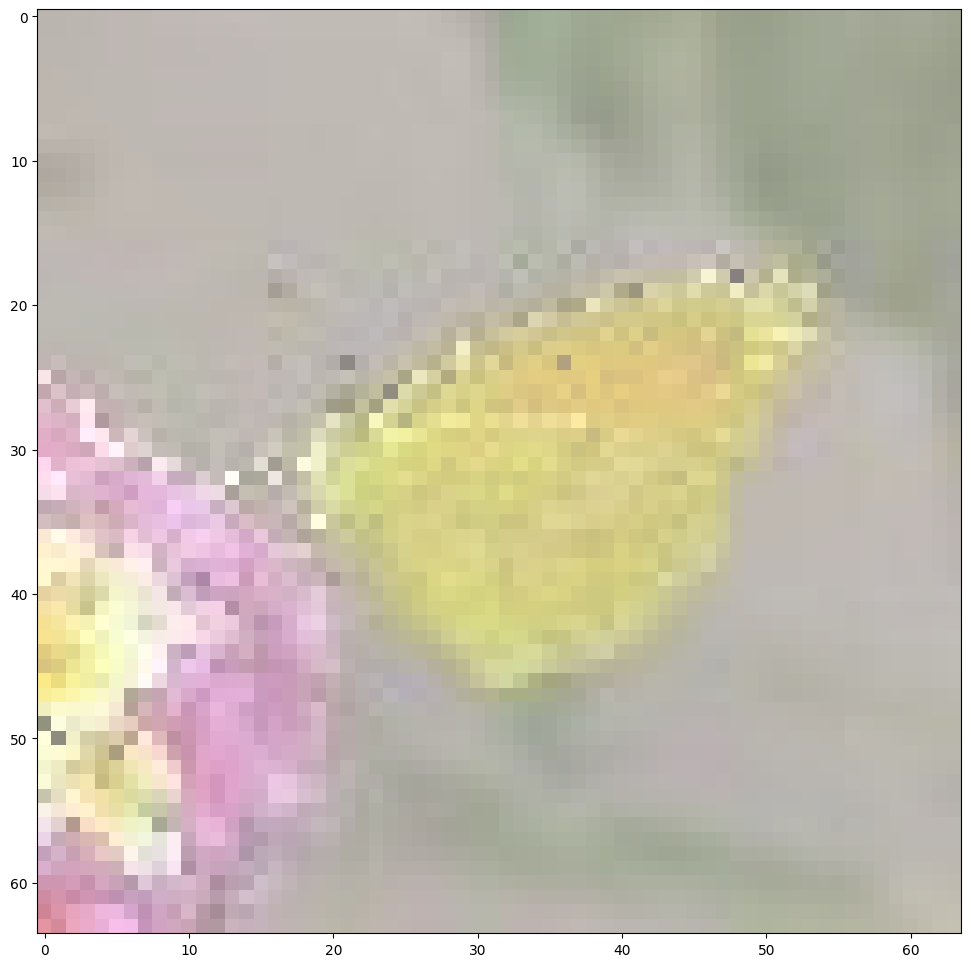

In [33]:
images, labels = next(iter(base_train_dataset))

plt.figure(figsize=(12, 12))
# create grid of images
img_grid = torchvision.utils.make_grid(images)
# show images
matplotlib_imshow(img_grid, one_channel=False)

In [34]:
images.shape

torch.Size([3, 64, 64])

In [35]:
# YOU CAN DEFINE AUGMENTATIONS HERE
train_path = './dataset/dataset/train'
val_path = './dataset/dataset/val'

train_transform = transforms.Compose([transforms.ToTensor(),
                                      Normalize(mean=train_mean, std=train_std),
                                      RandomHorizontalFlip(p=0.5),
                                      RandomRotation(degrees=15),])
val_transform = transforms.Compose([transforms.ToTensor(),
                                    Normalize(mean=train_mean, std=train_std)])

train_dataset = ImageFolder(train_path, transform=train_transform)
val_dataset = ImageFolder(val_path, transform=val_transform)
# REPLACE ./dataset/dataset WITH THE FOLDER WHERE YOU DOWNLOADED AND UNZIPPED THE DATASET

train_dataloader = DataLoader(train_dataset, batch_size=256, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=256)

In [36]:
# Just very simple sanity checks
assert isinstance(train_dataset[0], tuple)
assert len(train_dataset[0]) == 2
assert isinstance(train_dataset[1][1], int)
print("tests passed")

tests passed


### Посмотрим на картиночки

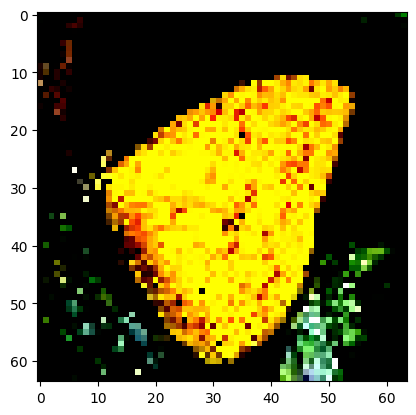

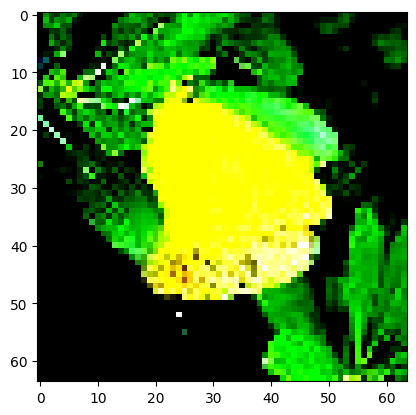

In [37]:
for batch in val_dataloader:
    images, class_nums = batch
    plt.imshow(images[7].permute(1, 2, 0))
    plt.show()
    plt.imshow(images[19].permute(1, 2, 0))
    plt.show()
    break

## Задание 1.

5 баллов
Добейтесь accuracy на валидации не менее 0.44. В этом задании запрещено пользоваться предобученными моделями и ресайзом картинок.


Для того чтобы выбить скор (считается ниже) на 2.5/5 балла (то есть половину за задание) достаточно соблюдать пару простых жизненных правил:
1. Аугментация (без нее сложно очень будет)
2. Оптимайзеры можно (и нужно) использовать друг с другом. Однако когда что-то проверяете, то не меняйте несколько параметров сразу - собьете логику экспериментов
3. Не используйте полносвязные модели или самые первые сверточные, используйте более современные архитектуры (что на лекциях встречались)
4. Посмотреть все ноутбуки прошедших семинаров и слепить из них что-то общее. Семинарских тетрадок хватит сверх

### Модель (или просто импортируйте не предобученную)

In [38]:
class YourNet(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.cv1 = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1),
            nn.BatchNorm2d(64, eps=1e-05, momentum=0.1),
            nn.ReLU(),

        )

        self.cv2 = nn.Sequential(
            nn.Conv2d(64, 64, 3, padding=1),
            nn.BatchNorm2d(64, eps=1e-05, momentum=0.1),
            nn.ReLU(),
            # nn.Conv2d(64, 64, 3, padding=1),
            # nn.BatchNorm2d(64, eps=1e-05, momentum=0.1),
            nn.MaxPool2d(3, stride=2, padding=1)
        )

        self.cv3 = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128, eps=1e-05, momentum=0.1),
            nn.ReLU(),

        )


        self.cv4 = nn.Sequential(
            nn.Conv2d(128, 128, 3, padding=1),
            nn.BatchNorm2d(128, eps=1e-05, momentum=0.1),
            nn.ReLU(),
            # nn.Conv2d(128, 128, 3, padding=1),
            # nn.BatchNorm2d(128, eps=1e-05, momentum=0.1),
            nn.MaxPool2d(3, stride=2, padding=1)
        )

        self.cv5 = nn.Sequential(
            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256, eps=1e-05, momentum=0.1),
            nn.ReLU(),

        )

        self.cv6 = nn.Sequential(
            nn.Conv2d(256, 256, 3, padding=1),
            nn.BatchNorm2d(256, eps=1e-05, momentum=0.1),
            nn.ReLU(),
            nn.MaxPool2d(3, stride=2, padding=1)
        )

        self.cv7 = nn.Sequential(
            nn.Conv2d(256, 512, 3, padding=1),
            nn.BatchNorm2d(512, eps=1e-05, momentum=0.1),
            nn.ReLU(),
        )


        self.relu = nn.ReLU()
        self.fc1 = nn.Linear(512 * 8 * 8, 1024)
        self.fc2 = nn.Linear(1024, 512)
        self.output = nn.Linear(512, 200)
        self.dropout = nn.Dropout(0.3)

        self.correct = 0
        self.total = 0

    def _forward(self, x):
        x = self.cv1(x)
        x = self.cv2(x)
        x = self.cv3(x)
        x = self.cv4(x)
        x = self.cv5(x)
        x = self.cv6(x)
        x = self.cv7(x)
        x = nn.Flatten()(x)
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        return self.output(x)

    def forward(self, images, target=None):
        output = self._forward(images)
        if target is not None:
            loss = F.cross_entropy(output, target)

            pred = output.argmax(dim=1)
            self.correct += (pred == target).sum().item()
            self.total += target.size(0)
            return loss

        return output


    def get_accuracy(self, reset=False):
        if self.total == 0:
            return 0.0

        accuracy = self.correct / self.total

        if reset:
            self.correct = 0
            self.total = 0

        return accuracy

### Тренировочный класс lightning

In [39]:
class YourModule(pl.LightningModule):
    def __init__(self, model, learning_rate):
        super().__init__()
        self.model = model
        self.learning_rate = learning_rate


    def forward(self, x):
        result = self.model(x)
        return result

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=self.learning_rate)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer,
            T_max=15,
            eta_min=1e-6
        )
        return [optimizer], [scheduler]

    def training_step(self, train_batch, batch_idx):
        images, target = train_batch
        loss = self.model(images, target)
        self.log(
            'train_loss', loss, prog_bar=True
        )
        return loss

    def validation_step(self, val_batch, batch_idx):
        images, target = val_batch
        loss = self.model(images, target)
        self.log(
            'val_loss', loss, prog_bar=True
        )

In [40]:
#wandb_logger = WandbLogger(log_model='all')  какие возможности дает с pytorch_lightning https://docs.wandb.ai/guides/integrations/lightning
device = 'cuda' if torch.cuda.is_available() else 'cpu'

model = YourNet().to(device)
module = YourModule(model, learning_rate=0.001)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.trainer.connectors.checkpoint_connector:`weights_only` was not set, defaulting to `False`.
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` 

Finding best initial lr:   0%|          | 0/100 [00:00<?, ?it/s]

INFO:pytorch_lightning.tuner.lr_finder:LR finder stopped early after 94 steps due to diverging loss.
INFO:pytorch_lightning.utilities.rank_zero:Restoring states from the checkpoint path at /content/.lr_find_bf3a69de-617d-470d-a7f2-2e94b9457381.ckpt
INFO:pytorch_lightning.utilities.rank_zero:Restored all states from the checkpoint at /content/.lr_find_bf3a69de-617d-470d-a7f2-2e94b9457381.ckpt
INFO:pytorch_lightning.tuner.lr_finder:Learning rate set to 0.00031622776601683794


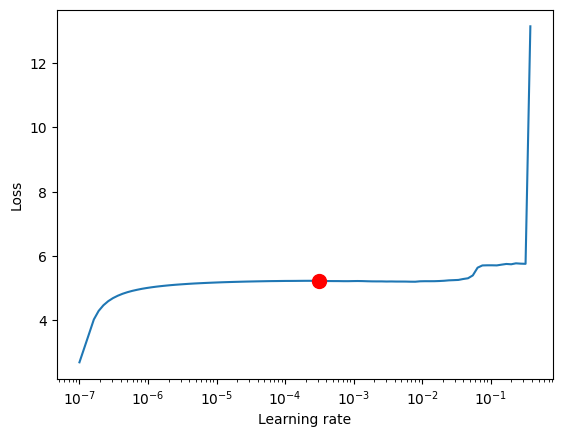

In [41]:
trainer = pl.Trainer(max_epochs=15, enable_progress_bar=True, logger=True)

tuner = Tuner(trainer=trainer)

lr_finder = tuner.lr_find(
    module,
    train_dataloaders=train_dataloader,
    val_dataloaders=val_dataloader,
    min_lr=1e-7,
    max_lr=1,
    num_training=100,
    mode='exponential',
)
suggested_lr = lr_finder.suggestion()
# print(f"Рекомендованный LR: {suggested_lr}")

fig = lr_finder.plot(suggest=True)
fig.show()

In [ ]:
model.learning_rate = suggested_lr
trainer.fit(module, train_dataloader, val_dataloader)

INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━┳━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name  ┃ Type    ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━╇━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model │ YourNet │ 36.5 M │ train │     0 │
└───┴───────┴─────────┴────────┴───────┴───────┘

Trainable params: 36.5 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 36.5 M                                                                                               
Total estimated model params size (MB): 146                                                                        
Modules in train mode: 37                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=15` reached.


### Валидация результатов задания

In [ ]:
def evaluate_task(model, test_dataloader, device="cuda:0"):
    model = model.to(device)
    model.eval()
    accuracy = 0.0
    for images, labels in tqdm(test_dataloader):
        images, labels = images.to(device), labels.to(device)
        with torch.no_grad():
            loss = model(images, labels)
            acc_batch = model.get_accuracy(reset=True)
        accuracy += acc_batch
    accuracy = accuracy / len(test_dataloader)
    return accuracy

In [ ]:
model = model

accuracy = evaluate_task(model, val_dataloader)
print(f"Оценка за это задание составит {np.clip(10 * accuracy / 0.44, 0, 10):.2f} баллов")

100%|██████████| 40/40 [00:08<00:00,  4.69it/s]

Оценка за это задание составит 10.00 баллов


In [ ]:
accuracy

0.47574267820137583

## Задание 2

5 баллов
Добейтесь accuracy на валидации не менее 0.84. В этом задании делать ресайз и использовать претрейн можно.

Для того чтобы выбить скор (считается ниже) на 2.5/5 балла (то есть половину за задание) достаточно соблюдать пару простых жизненных правил:
1. Аугментация (без нее сложно очень будет)
2. Оптимайзеры можно (и нужно) использовать друг с другом. Однако когда что-то проверяете, то не меняйте несколько параметров сразу - собьете логику экспериментов
3. Не используйте полносвязные модели или самые первые сверточные, используйте более современные архитектуры (что на лекциях встречались или можете пойти дальше).
4. Попробуйте сначала посмотреть качество исходной модели без дообучения, сохраните как baseline. Отсюда поймете какие слои нужно дообучать.
5. Посмотреть все ноутбуки прошедших семинаров и слепить из них что-то общее. Семинарских тетрадок хватит сверх

In [ ]:
# YOU CAN DEFINE AUGMENTATIONS HERE
train_path = './dataset/dataset/train'
val_path = './dataset/dataset/val'

img_size = 224

train_transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),   #  64->224
    transforms.RandomHorizontalFlip(),
    RandomRotation(degrees=15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.480, 0.448, 0.398],
                         std=[0.272, 0.265, 0.274]),
])

val_transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.480, 0.448, 0.398],
                         std=[0.272, 0.265, 0.274]),
])


train_dataset = ImageFolder(train_path, transform=train_transform)
val_dataset = ImageFolder(val_path, transform=val_transform)

train_dataloader = DataLoader(train_dataset, batch_size=256, shuffle=True, num_workers=6)
val_dataloader = DataLoader(val_dataset, batch_size=256, num_workers=6)

### Модель (или просто импортируйте предобученную)

In [7]:
class YourNet(torch.nn.Module):
    def __init__(self):
        super().__init__()
        # YOUR CODE HERE
        pass

    def _forward(self, x):
        # runs the Neural Network
        # YOUR CODE HERE
        pass

    def forward(self, images, target=None):
        # YOUR CODE HERE
        pass

    def get_accuracy(self, reset=False):
        # YOUR CODE HERE
        pass

### Тренировочный класс lightning

In [13]:
class YourModule(pl.LightningModule):
    def __init__(self, learning_rate=1e-3, freeze_backbone=True):
        super().__init__()
        self.save_hyperparameters()

        backbone = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
        self.feature_extractor = nn.Sequential(*list(backbone.children())[:-1])

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(2048, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(),
            nn.Dropout(0.35),
            nn.Linear(1024, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Linear(512, 200),
        )

        self.train_acc = torchmetrics.Accuracy(task="multiclass", num_classes=200)
        self.val_acc   = torchmetrics.Accuracy(task="multiclass", num_classes=200)
        self._eval_acc = torchmetrics.Accuracy(task="multiclass", num_classes=200)

        if freeze_backbone:
            self._freeze_backbone()

    def _freeze_backbone(self):
        for param in self.feature_extractor.parameters():
            param.requires_grad = False

        for module in self.feature_extractor.modules():
            if isinstance(module, nn.BatchNorm2d):
                module.eval()

    def _unfreeze_backbone(self):
        for param in self.feature_extractor.parameters():
            param.requires_grad = True

        for module in self.feature_extractor.modules():
            if isinstance(module, nn.BatchNorm2d):
                module.train()

    def _unfreeze_last_layers(self, n_layers=2):
        children = list(self.feature_extractor.children())
        for layer in children[-n_layers:]:
            for param in layer.parameters():
                param.requires_grad = True

    def on_train_epoch_start(self):
        if self.hparams.freeze_backbone:
            for module in self.feature_extractor.modules():
                if isinstance(module, nn.BatchNorm2d):
                    module.eval()

    def forward(self, x, labels=None):
        features = self.feature_extractor(x)
        logits = self.classifier(features)

        if labels is not None:
            self._eval_acc.update(logits, labels)
            return nn.functional.cross_entropy(logits, labels)

        return logits

    def get_accuracy(self, reset=True):
        acc = self._eval_acc.compute().item()
        if reset:
            self._eval_acc.reset()
        return acc

    def configure_optimizers(self):
        backbone_params    = [p for p in self.feature_extractor.parameters() if p.requires_grad]
        classifier_params  = list(self.classifier.parameters())

        param_groups = [{"params": classifier_params, "lr": self.hparams.learning_rate}]
        if backbone_params:
            param_groups.append(
                {"params": backbone_params, "lr": self.hparams.learning_rate * 0.1}
            )

        optimizer = torch.optim.AdamW(param_groups, weight_decay=1e-4)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)
        return {"optimizer": optimizer, "lr_scheduler": scheduler}

    def training_step(self, train_batch, batch_idx):
        x, y = train_batch
        logits = self.classifier(self.feature_extractor(x))
        loss = nn.functional.cross_entropy(logits, y)
        self.train_acc(logits, y)
        self.log("train_loss", loss, on_epoch=True, prog_bar=True)
        self.log("train_acc",  self.train_acc, on_epoch=True, prog_bar=True)
        return loss

    def validation_step(self, val_batch, batch_idx):
        x, y = val_batch
        logits = self.classifier(self.feature_extractor(x))
        loss = nn.functional.cross_entropy(logits, y)
        self.val_acc(logits, y)
        self.log("val_loss", loss, prog_bar=True)
        self.log("val_acc",  self.val_acc, prog_bar=True)

In [14]:
# wandb_logger = WandbLogger(log_model='all') # какие возможности дает с pytorch_lightning https://docs.wandb.ai/guides/integrations/lightning
device = 'cuda' if torch.cuda.is_available() else 'cpu'

#model = YourNet().to()
module = YourModule(1e-3, True)

In [15]:
module

YourModule(
  (feature_extractor): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(
          (0)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.trainer.connectors.checkpoint_connector:`weights_only` was not set, defaulting to `False`.
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` 

Finding best initial lr:   0%|          | 0/100 [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=100` reached.
INFO:pytorch_lightning.utilities.rank_zero:Restoring states from the checkpoint path at /content/.lr_find_54e88c7f-6288-4cb6-85e6-f04d55c7b1eb.ckpt
INFO:pytorch_lightning.utilities.rank_zero:Restored all states from the checkpoint at /content/.lr_find_54e88c7f-6288-4cb6-85e6-f04d55c7b1eb.ckpt
INFO:pytorch_lightning.tuner.lr_finder:Learning rate set to 0.0002691534803926915


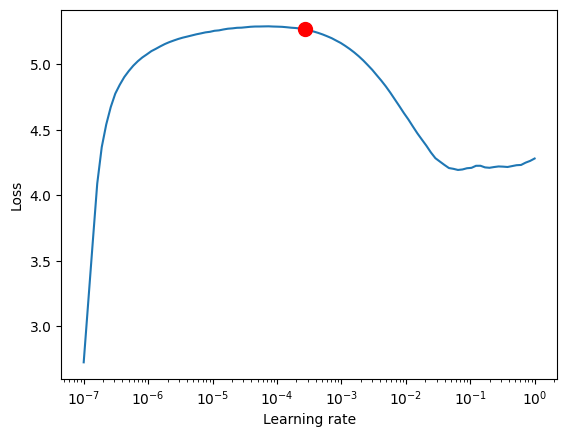

In [16]:
trainer = pl.Trainer(max_epochs=6, enable_progress_bar=True, logger=True, accelerator='auto', log_every_n_steps=10)

tuner = Tuner(trainer=trainer)

lr_finder = tuner.lr_find(
    module,
    train_dataloaders=train_dataloader,
    val_dataloaders=val_dataloader,
    min_lr=1e-7,
    max_lr=1,
    num_training=100,
    mode='exponential',
)
suggested_lr = lr_finder.suggestion()
# print(f"LR: {suggested_lr}")


fig = lr_finder.plot(suggest=True)
fig.show()

In [17]:
module.lr = suggested_lr
trainer.fit(module, train_dataloader, val_dataloader)

INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name              ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ feature_extractor │ Sequential         │ 23.5 M │ train │     0 │
│ 1 │ classifier        │ Sequential         │  2.7 M │ train │     0 │
│ 2 │ train_acc         │ MulticlassAccuracy │      0 │ train │     0 │
│ 3 │ val_acc           │ MulticlassAccuracy │      0 │ train │     0 │
│ 4 │ _eval_acc         │ MulticlassAccuracy │      0 │ train │     0 │
└───┴───────────────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 2.7 M                                                                                            
Non-trainable params: 23.5 M                                                                                       
Total params: 26.2 M                                                                                               
Total estimated model params size (MB): 104                                                                        
Modules in train mode: 110                                                                                         
Modules in eval mode: 53                                                                                           
Total FLOPs: 0

Output()

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)`
is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will 
create 6 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller 
than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader 
running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/loops/fit_loop.py:534: Found 53 module(s) in eval mode at
the start of training. This may lead to unexpected behavior during training. If this is intentional, you can ignore
this warning.

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=6` reached.


In [20]:
model = module

accuracy = evaluate_task(model, val_dataloader)
print(f"Оценка за это задание составит {np.clip(10 * (accuracy - 0.5) / 0.34, 0, 10):.2f} баллов")
print(f'Accuracy {accuracy}')


100%|██████████| 40/40 [00:39<00:00,  1.00it/s]

Оценка за это задание составит 7.91 баллов
Accuracy 0.76884765625


In [ ]:
module._unfreeze_backbone()
module.hparams.freeze_backbone = False
module.hparams.learning_rate = 5e-5

trainer2 = pl.Trainer(max_epochs=6, enable_progress_bar=True, logger=True, accelerator='auto', log_every_n_steps=10)


In [ ]:
train_dataloader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=6)
val_dataloader = DataLoader(val_dataset, batch_size=64, num_workers=6)

In [26]:
import os
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'

In [27]:
trainer2.fit(module, train_dataloader, val_dataloader)

INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━┳━━━━━━━┓
┃   ┃ Name              ┃ Type               ┃ Params ┃ Mode ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━╇━━━━━━━┩
│ 0 │ feature_extractor │ Sequential         │ 23.5 M │ eval │     0 │
│ 1 │ classifier        │ Sequential         │  2.7 M │ eval │     0 │
│ 2 │ train_acc         │ MulticlassAccuracy │      0 │ eval │     0 │
│ 3 │ val_acc           │ MulticlassAccuracy │      0 │ eval │     0 │
│ 4 │ _eval_acc         │ MulticlassAccuracy │      0 │ eval │     0 │
└───┴───────────────────┴────────────────────┴────────┴──────┴───────┘

Trainable params: 26.2 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 26.2 M                                                                                               
Total estimated model params size (MB): 104                                                                        
Modules in train mode: 0                                                                                           
Modules in eval mode: 163                                                                                          
Total FLOPs: 0

Output()

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/loops/fit_loop.py:534: Found 164 module(s) in eval mode 
at the start of training. This may lead to unexpected behavior during training. If this is intentional, you can 
ignore this warning.

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=6` reached.


### Валидация результатов задания

In [19]:
def evaluate_task(model, test_dataloader, device="cuda:0"):
    model = model.to(device)
    model.eval()
    accuracy = 0.0
    for images, labels in tqdm(test_dataloader):
        images, labels = images.to(device), labels.to(device)
        with torch.no_grad():
            loss = model(images, labels)
            acc_batch = model.get_accuracy(reset=True)
        accuracy += acc_batch
    accuracy = accuracy / len(test_dataloader)
    return accuracy

In [28]:
model = module

accuracy = evaluate_task(model, val_dataloader)
print(f"Оценка за это задание составит {np.clip(10 * (accuracy - 0.5) / 0.34, 0, 10):.2f} баллов")


  0%|          | 0/157 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 6 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()

100%|██████████| 157/157 [00:38<00:00,  4.12it/s]

Оценка за это задание составит 8.98 баллов


In [ ]:
accuracy